# Feature importance from ML models (research columns)

We use the **imputed research columns** (`ml_households_research_columns_imputed.csv`, 27–28 columns) to train several ML models predicting **household_income_total** (regression). For each model we extract feature importance (or coefficients), save results to **separate CSVs**, and plot visualizations.

**Target:** `household_income_total` (Armenian Drams, AMD)  
**Features:** All other numeric columns from the research set (27 features).  
**Output:** One CSV per model in `data/ilcs/research/feature_importance/`, plus bar charts and a comparison plot.

## 1. Load data and prepare target and features

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
RESEARCH_CSV = DATA_DIR / "research" / "ml_households_research_columns_imputed.csv"
OUT_DIR = DATA_DIR / "research" / "feature_importance"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "household_income_total"
df = pd.read_csv(RESEARCH_CSV, low_memory=False)
_EXCLUDE = {TARGET, 'interview_month'}   # interview_month = temporal ID, not a predictor
feature_cols = [c for c in df.columns if c not in _EXCLUDE and np.issubdtype(df[c].dtype, np.number)]
X = df[feature_cols]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Hybrid scaling (column-type-aware, based on test_ideas/experiments.py analysis) ─────
# log1p + StandardScaler → monetary / heavily skewed AMD columns
_LOG_STD = [
    'potable_water_hours_day', 'heating_spend_last_winter_amd', 'family_debt_amount',
    'money_family_need_monthly_live', 'drm_in_amd', 'money_family_need_monthly_make',
    'amd_3', 'food_purchases_total', 'services_goods_total', 'goods_services_total',
]
# RobustScaler → ordinal / count variables
_ROBUST = [
    'household_size', 'dwelling_ownership', 'number_of_rooms', 'has_other_dwelling',
    'dwelling_condition_estimate', 'registered_poverty_benefit',
    'share_families_really_vulnerable', 'household_income_source_count',
]
# MinMaxScaler → binary / ternary survey codes
_MINMAX = [
    'has_computer', 'household_has_car', 'dwelling_renovated', 'building_new_house',
    'household_sent_money_goods_12m', 'household_received_money_goods_12m',
    'lent_money_12m', 'borrowed_money_12m', 'humanitarian_assistance_12m',
]

def _fit_hybrid(X_df):
    """Fit hybrid scalers on training DataFrame."""
    scalers = {}
    ls = [c for c in _LOG_STD if c in X_df.columns]
    rb = [c for c in _ROBUST  if c in X_df.columns]
    mm = [c for c in _MINMAX  if c in X_df.columns]
    if ls:
        scalers['log_std'] = (StandardScaler().fit(np.log1p(X_df[ls].values)), ls)
    if rb:
        scalers['robust']  = (RobustScaler().fit(X_df[rb].values), rb)
    if mm:
        scalers['minmax']  = (MinMaxScaler().fit(X_df[mm].values), mm)
    return scalers

def _transform_hybrid(X_df, scalers):
    """Apply fitted hybrid scalers; returns numpy array."""
    out = X_df.copy().astype(float)
    for key, (sc, cols) in scalers.items():
        if key == 'log_std':
            out[cols] = sc.transform(np.log1p(X_df[cols].values))
        else:
            out[cols] = sc.transform(X_df[cols].values)
    return out.values

_scalers = _fit_hybrid(X_train)
X_train_s = _transform_hybrid(X_train, _scalers)
X_test_s  = _transform_hybrid(X_test,  _scalers)

MODEL_METRICS = {}   # collects {model_name: {R², MSE, MAE}} for comparison table

n_ls = len([c for c in _LOG_STD if c in feature_cols])
n_rb = len([c for c in _ROBUST  if c in feature_cols])
n_mm = len([c for c in _MINMAX  if c in feature_cols])
print(f"Target: {TARGET}")
print(f"Features: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Hybrid scaling: log1p+Std={n_ls}, Robust={n_rb}, MinMax={n_mm} columns")


## 2. Random Forest — feature importance

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
r2_rf  = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
MODEL_METRICS['RF'] = {'R²': r2_rf, 'MSE': mse_rf, 'MAE': mae_rf}
print(f"Random Forest — R²: {r2_rf:.4f} | MSE: {mse_rf:,.0f} AMD² | MAE: {mae_rf:,.0f} AMD")

imp_rf = (pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
          .sort_values("importance", ascending=False))
imp_rf.to_csv(OUT_DIR / "feature_importance_rf.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_rf, y="feature", x="importance", ax=ax, color="steelblue")
ax.set_title(f"Feature Importance — Random Forest\n(R²={r2_rf:.4f}, MAE={mae_rf:,.0f} AMD, target: Total Household Income)",
             fontsize=11)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_rf.csv'}")


## 3. Gradient Boosting — feature importance

In [ ]:
gbm = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbm.fit(X_train_s, y_train)
y_pred_gbm = gbm.predict(X_test_s)
r2_gbm  = r2_score(y_test, y_pred_gbm)
mse_gbm = mean_squared_error(y_test, y_pred_gbm)
mae_gbm = mean_absolute_error(y_test, y_pred_gbm)
MODEL_METRICS['GBM'] = {'R²': r2_gbm, 'MSE': mse_gbm, 'MAE': mae_gbm}
print(f"Gradient Boosting — R²: {r2_gbm:.4f} | MSE: {mse_gbm:,.0f} AMD² | MAE: {mae_gbm:,.0f} AMD")

imp_gbm = (pd.DataFrame({"feature": feature_cols, "importance": gbm.feature_importances_})
           .sort_values("importance", ascending=False))
imp_gbm.to_csv(OUT_DIR / "feature_importance_gbm.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_gbm, y="feature", x="importance", ax=ax, color="darkgreen")
ax.set_title(f"Feature Importance — Gradient Boosting\n(R²={r2_gbm:.4f}, MAE={mae_gbm:,.0f} AMD, target: Total Household Income)",
             fontsize=11)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_gbm.csv'}")


## 4. Extra Trees — feature importance

In [ ]:
et = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et.fit(X_train_s, y_train)
y_pred_et = et.predict(X_test_s)
r2_et  = r2_score(y_test, y_pred_et)
mse_et = mean_squared_error(y_test, y_pred_et)
mae_et = mean_absolute_error(y_test, y_pred_et)
MODEL_METRICS['ExtraTrees'] = {'R²': r2_et, 'MSE': mse_et, 'MAE': mae_et}
print(f"Extra Trees — R²: {r2_et:.4f} | MSE: {mse_et:,.0f} AMD² | MAE: {mae_et:,.0f} AMD")

imp_et = (pd.DataFrame({"feature": feature_cols, "importance": et.feature_importances_})
          .sort_values("importance", ascending=False))
imp_et.to_csv(OUT_DIR / "feature_importance_extra_trees.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_et, y="feature", x="importance", ax=ax, color="coral")
ax.set_title(f"Feature Importance — Extra Trees\n(R²={r2_et:.4f}, MAE={mae_et:,.0f} AMD, target: Total Household Income)",
             fontsize=11)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_extra_trees.csv'}")


## 5. Ridge — coefficient magnitude as importance

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
r2_ridge  = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
MODEL_METRICS['Ridge'] = {'R²': r2_ridge, 'MSE': mse_ridge, 'MAE': mae_ridge}
print(f"Ridge — R²: {r2_ridge:.4f} | MSE: {mse_ridge:,.0f} AMD² | MAE: {mae_ridge:,.0f} AMD")

imp_ridge = (pd.DataFrame({"feature": feature_cols, "importance": np.abs(ridge.coef_)})
             .sort_values("importance", ascending=False))
imp_ridge.to_csv(OUT_DIR / "feature_importance_ridge.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_ridge, y="feature", x="importance", ax=ax, color="purple")
ax.set_title(f"Feature Importance — Ridge Regression (|coefficient|)\n(R²={r2_ridge:.4f}, MAE={mae_ridge:,.0f} AMD, target: Total Household Income)",
             fontsize=11)
ax.set_xlabel("Importance (absolute coefficient value)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_ridge.csv'}")


## 6. Lasso — coefficient magnitude as importance

In [ ]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=5000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
r2_lasso  = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
MODEL_METRICS['Lasso'] = {'R²': r2_lasso, 'MSE': mse_lasso, 'MAE': mae_lasso}
print(f"Lasso — R²: {r2_lasso:.4f} | MSE: {mse_lasso:,.0f} AMD² | MAE: {mae_lasso:,.0f} AMD")

imp_lasso = (pd.DataFrame({"feature": feature_cols, "importance": np.abs(lasso.coef_)})
             .sort_values("importance", ascending=False))
imp_lasso.to_csv(OUT_DIR / "feature_importance_lasso.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp_lasso, y="feature", x="importance", ax=ax, color="darkred")
ax.set_title(f"Feature Importance — Lasso Regression (|coefficient|)\n(R²={r2_lasso:.4f}, MAE={mae_lasso:,.0f} AMD, target: Total Household Income)",
             fontsize=11)
ax.set_xlabel("Importance (absolute coefficient value)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()
print(f"Saved: {OUT_DIR / 'feature_importance_lasso.csv'}")


## 7. Comparison across models

We merge importance from all models and plot a grouped bar chart (top features) and a heatmap (all features, normalized per model).

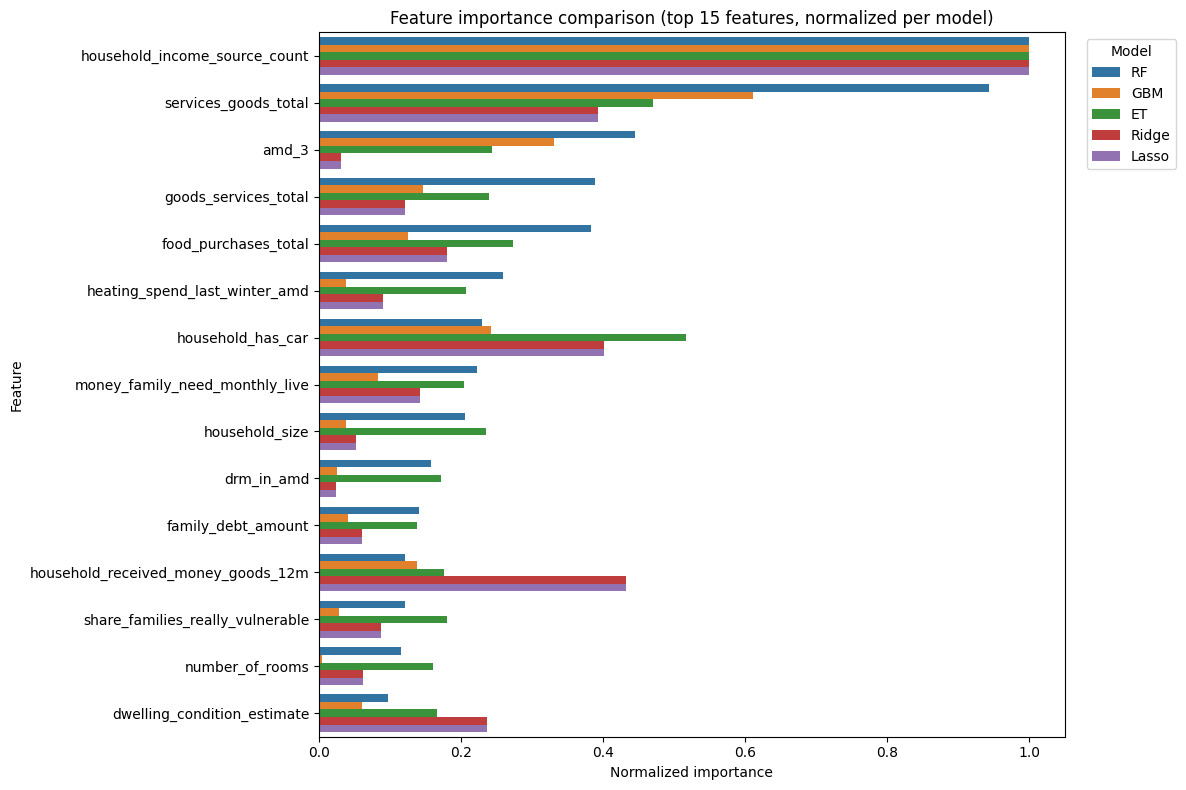

In [7]:
all_imp = imp_rf.rename(columns={"importance": "RF"}).merge(
    imp_gbm.rename(columns={"importance": "GBM"})[["feature", "GBM"]], on="feature"
).merge(
    imp_et.rename(columns={"importance": "ET"})[["feature", "ET"]], on="feature"
).merge(
    imp_ridge.rename(columns={"importance": "Ridge"})[["feature", "Ridge"]], on="feature"
).merge(
    imp_lasso.rename(columns={"importance": "Lasso"})[["feature", "Lasso"]], on="feature"
)
all_imp_norm = all_imp.copy()
for col in ["RF", "GBM", "ET", "Ridge", "Lasso"]:
    all_imp_norm[col] = all_imp_norm[col] / all_imp_norm[col].max()
top_n = 15
top_features = imp_rf.head(top_n)["feature"].tolist()
plot_df = all_imp_norm[all_imp_norm["feature"].isin(top_features)].melt(
    id_vars="feature", var_name="model", value_name="importance_norm"
)
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=plot_df, x="importance_norm", y="feature", hue="model", ax=ax)
ax.set_title(f"Feature importance comparison (top {top_n} features, normalized per model)")
ax.set_xlabel("Normalized importance")
ax.set_ylabel("Feature")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

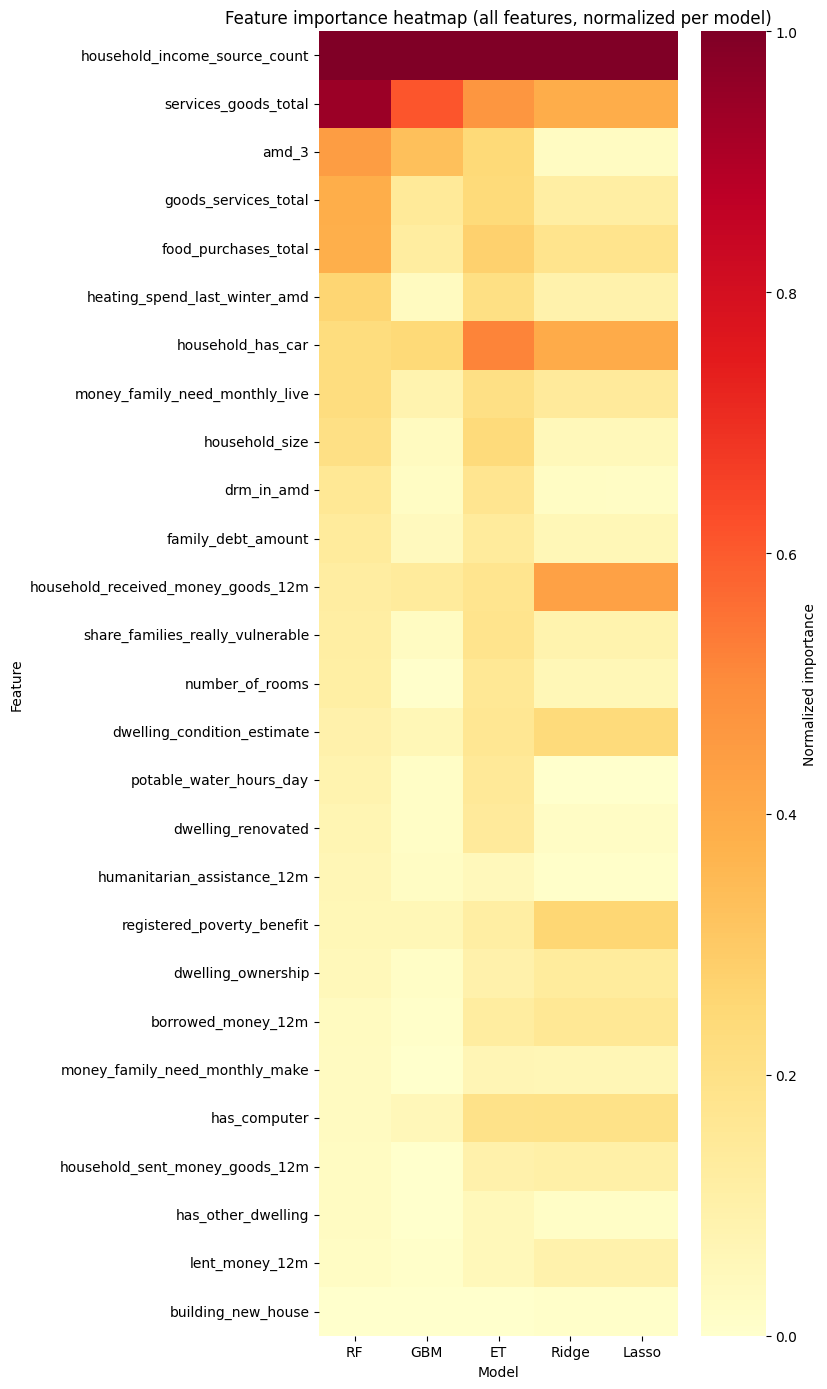

In [8]:
heatmap_df = all_imp_norm.set_index("feature")[["RF", "GBM", "ET", "Ridge", "Lasso"]]
fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(heatmap_df, annot=False, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Normalized importance"})
ax.set_title("Feature importance heatmap (all features, normalized per model)")
ax.set_xlabel("Model")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ── Model performance metrics comparison table ─────────────────────────────
metrics_df = pd.DataFrame(MODEL_METRICS).T.rename_axis("Model")
metrics_df['RMSE'] = np.sqrt(metrics_df['MSE'])
metrics_df = metrics_df[['R²', 'MAE', 'RMSE', 'MSE']].round({'R²': 4, 'MAE': 0, 'RMSE': 0, 'MSE': 0})
print("═" * 60)
print("MODEL PERFORMANCE COMPARISON (target: household_income_total)")
print("═" * 60)
print(metrics_df.to_string())
print("\nNote: MAE/RMSE/MSE in Armenian Drams (AMD)")

# Bar chart: R² per model
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Model Performance — Predicting Total Household Income (AMD)", fontsize=12, y=1.02)

colors = ['steelblue', 'darkgreen', 'coral', 'purple', 'darkred']
models = metrics_df.index.tolist()

axes[0].bar(models, metrics_df['R²'], color=colors, edgecolor='white')
axes[0].set_title("R² Score (higher = better)")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(metrics_df['R²']):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

axes[1].bar(models, metrics_df['MAE'], color=colors, edgecolor='white')
axes[1].set_title("MAE — Mean Absolute Error (AMD)")
axes[1].set_ylabel("MAE (AMD)")
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(models, metrics_df['RMSE'], color=colors, edgecolor='white')
axes[2].set_title("RMSE (AMD)")
axes[2].set_ylabel("RMSE (AMD)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 8. Model performance comparison